# 04 – AutoML with PyCaret: Secondary Mushroom

**Worked on by:** Andreas Schellekens (PyCaret setup, model comparison, tuning and blending check, test evaluation); Mihai Constantin (re-run and check of the results on a second machine, text corrections after a review)

> **GenAI disclosure:** the first version of this notebook was drafted with the help of Claude Code (AI assistant), based on the decisions in `01_eda.ipynb` to `03_model_baseline.ipynb`. All steps were reviewed by the team; we must be able to explain every cell ourselves.

## 1. Setup & loading

PyCaret trains and cross-validates many model types with a few lines of code. We use it to answer one question quickly: **which kinds of models work best on this data?** The answer decides which models we tune by hand in the `05_model_*` notebooks.

**A technical workaround:** in our environment (Windows, PyCaret 3.3.2, LightGBM 4.7) LightGBM crashes with `access violation reading 0x0000000000000000` as soon as PyCaret has been imported first. LightGBM itself works, and so does PyCaret without LightGBM: the two load conflicting native libraries (DLLs), and whichever package is loaded first wins. Two measures solve it:
1. `import lightgbm` **before** PyCaret, so LightGBM's libraries are loaded first.
2. `n_jobs=1` in `setup`, so the cross-validation folds run in this process. With parallel folds, PyCaret starts worker processes that import PyCaret first, and there the crash comes back.

The cost is speed (the comparison takes about half a minute instead of 15 seconds), which is negligible for 3500 rows.

In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

from pathlib import Path

import lightgbm  # noqa: F401  (must be imported before pycaret, see above)
import matplotlib.pyplot as plt
import pandas as pd
from pycaret.classification import (blend_models, compare_models, get_config, plot_model, predict_model, pull,
                                    save_model, setup, tune_model)
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score, precision_score,
                             recall_score, roc_auc_score)

DATA_DIR = Path("Data")
MODEL_DIR = Path("models")
MODEL_PATH = MODEL_DIR / "mushroom_pycaret_rf"  # save_model adds .pkl
METRICS_PATH = MODEL_DIR / "metrics.csv"

NOTEBOOK = "04_model_automl"
RANDOM_STATE = 42
TARGET = "is_poisonous"
NUM_COLS = ["cap_diameter", "stem_height", "stem_width"]
CAT_COLS = ["spore_print_color", "gill_color", "habitat", "season", "ring_type", "cap_shape", "stem_surface", "has_stem"]


def data_path(split, kind):
    # Files made by 02_data_preparation.ipynb, e.g. Data/validation/mushroom_cleaned_validation.csv
    return DATA_DIR / split / f"mushroom_{kind}_{split}.csv"

PyCaret does its own imputation and encoding, so it gets the **cleaned** files from `02_data_preparation.ipynb` (readable labels, noise columns dropped, stem rule applied, categorical `NaN` → `"missing"`), not the prepared ones. Numerical `NaN` are still empty there, because the median must be learned on the training rows only.

We read the train, validation and test files from their folders, so PyCaret gets exactly the same 3500 / 750 / 750 rows as every other model notebook. The target becomes `is_poisonous` (1 = poisonous), as in the prepared files, so *poisonous* is the positive class for recall and precision.

In [2]:
def load_cleaned(split):
    frame = pd.read_csv(data_path(split, "cleaned"), index_col="row_id")
    frame[TARGET] = (frame.pop("class") == "poisonous").astype(int)
    return frame


train_df, val_df, test_df = (load_cleaned(split) for split in ["train", "validation", "test"])
print(f"Train: {train_df.shape}  |  Validation: {val_df.shape}  |  Test: {test_df.shape}")
print(f"Share poisonous – train: {train_df[TARGET].mean():.1%}  |  validation: {val_df[TARGET].mean():.1%}"
      f"  |  test: {test_df[TARGET].mean():.1%}")

Train: (3500, 12)  |  Validation: (750, 12)  |  Test: (750, 12)
Share poisonous – train: 37.9%  |  validation: 37.9%  |  test: 37.9%


## 2. PyCaret setup

`setup` defines the whole experiment: which data, which preprocessing, which validation. We keep it as close as possible to our own preparation, so differences between models come from the models and not from different preprocessing.

| Setting | Value | Why |
|---|---|---|
| `data` / `test_data` | our train / validation rows | PyCaret would otherwise make its own split. This way its hold-out set **is** our validation set, and the test set stays outside PyCaret's experiment until the final evaluation (section 5) |
| `numeric_features` / `categorical_features` | explicit lists | without them PyCaret guesses the types; `has_stem` (0/1) must be treated as a category |
| `numeric_imputation` | `"median"` | same as `02_data_preparation.ipynb` (missing at random, robust to skew). Categorical gaps (`has_stem` only) get the most frequent value, also as in 02 |
| `transformation` | `True` (Yeo-Johnson) | PyCaret has no `log1p` option; Yeo-Johnson is a power transform that also removes skew and works with zeros |
| `normalize` | `True` (z-score) | same as our `StandardScaler`, needed for linear models, KNN and SVM |
| `fold`, `fold_strategy` | 5, stratified | the same kind of cross-validation as in 02 and 03 (5 stratified folds), but not exactly the same folds: PyCaret does not shuffle before splitting (`fold_shuffle=False` by default) |
| `session_id` | 42 | reproducible results |
| `n_jobs` | 1 | LightGBM workaround (section 1) |

Categoricals are one-hot encoded (PyCaret does this for every column with at most 25 categories; ours have at most 13).

**Paths not taken:**
- *`fix_imbalance` (SMOTE, synthetic poisonous mushrooms)*: we handle the 62/38 imbalance with class weights and the decision threshold instead (notebook 03 showed that class weights shift the threshold without changing the ranking). Inventing extra rows in a dataset with ~2% suspected flipped labels risks copying those errors.
- *`rare_to_value` (grouping rare categories)*: a quick check with the same threshold as in 02 (10 rows) changed the random forest's AUC by only 0.002, so we keep PyCaret's default (no grouping).
- *`remove_multicollinearity`, `feature_selection`, `polynomial_features`*: only three numerical features and weakly related categoricals (EDA section 8), so there is little to remove, and the models that do well here (trees) find interactions themselves.

In [3]:
exp = setup(
    data=train_df,
    test_data=val_df,
    target=TARGET,
    numeric_features=NUM_COLS,
    categorical_features=CAT_COLS,
    numeric_imputation="median",
    transformation=True,
    normalize=True,
    fold=5,
    fold_strategy="stratifiedkfold",
    session_id=RANDOM_STATE,
    n_jobs=1,
    verbose=False,
    html=False,
)

# PyCaret's hold-out set must be exactly our validation set (same rows, same order)
assert get_config("X_test").index.equals(val_df.index)
print("Features after PyCaret preprocessing:", get_config("X_train_transformed").shape[1])

Features after PyCaret preprocessing: 65


## 3. Comparing all models

`compare_models` trains every classifier PyCaret knows with default settings and scores it with 5-fold cross-validation on the **training set**. The validation and test sets are not used here.

We sort on **AUC** (ROC-AUC), not on accuracy or recall:
- Recall at the default threshold of 0.5 mostly says where a model happens to put its threshold. Notebook 03 showed that the threshold can be moved afterwards (class weights), so a model with low recall but good AUC can still become a good poisonous-detector.
- AUC measures how well the model **ranks** poisonous mushrooms above edible ones, over all thresholds. That is the property we can't fix afterwards.

We keep the top 3 for the next step. XGBoost and CatBoost are not installed, so PyCaret skips them; LightGBM covers gradient boosting on trees.

In [4]:
top_models = compare_models(sort="AUC", n_select=3, verbose=False)
comparison = pull()
comparison

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.7783,0.8312,0.5683,0.7879,0.6599,0.5018,0.5168,2.020
lightgbm,Light Gradient Boosting Machine,0.7706,0.8160,0.5804,0.7570,0.6567,0.4890,0.4989,0.452
et,Extra Trees Classifier,0.7600,0.7968,0.5887,0.7263,0.6501,0.4705,0.4767,0.866
gbc,Gradient Boosting Classifier,0.7326,0.7687,0.4023,0.7894,0.5317,0.3714,0.4133,1.348
knn,K Neighbors Classifier,0.7437,0.7568,0.5351,0.7162,0.6122,0.4269,0.4372,1.382
ada,Ada Boost Classifier,0.6871,0.7078,0.3811,0.6475,0.4791,0.2768,0.2968,1.350
lr,Logistic Regression,0.6974,0.6973,0.3653,0.6906,0.4769,0.2918,0.3214,0.902
lda,Linear Discriminant Analysis,0.6940,0.6967,0.3464,0.6924,0.4608,0.2792,0.3122,0.402
ridge,Ridge Classifier,0.6943,0.6966,0.3404,0.6980,0.4567,0.2779,0.3129,0.922
dt,Decision Tree Classifier,0.6937,0.6748,0.5970,0.5960,0.5960,0.3495,0.3499,0.922


**Interpretation**
- **Tree ensembles win.** Random forest (AUC 0.831), LightGBM (0.816) and extra trees (0.797) are the top three. The random forest scores exactly what the same kind of model got in `02_data_preparation.ipynb` (0.831), so PyCaret's preprocessing is comparable to ours.
- **Linear models are in the bottom half** (logistic regression, LDA, ridge: AUC ≈ 0.70). PyCaret's logistic regression scores the same as our own unweighted version in notebook 03 (0.697), which confirms both results: the conclusion "linear is too weak" does not depend on our preprocessing.
- **KNN (0.757)** does better than the linear models: it is non-linear too (it compares a mushroom with its most similar neighbours), but it suffers from the 65 mostly one-hot dimensions.
- **Recall is below 0.6 for every good model** at threshold 0.5. The top models are *precise* (≈ 0.73–0.79: when they say poisonous, they are usually right) but miss more than 40% of the poisonous mushrooms. The single decision tree and QDA have the highest recall (0.60 and 0.64), but with a much worse AUC: they are not better at recognising poisonous mushrooms, they just say "poisonous" more often. This is exactly why we sort on AUC and fix recall with the threshold later.
- Accuracy differences between neighbours in the table are often smaller than the fold-to-fold variation (about 1–2 points, notebook 03), so only the big picture counts: trees ≫ KNN > linear > naive.

## 4. Can PyCaret improve the best model automatically?

PyCaret offers two cheap improvements:
- **`tune_model`**: a random search over PyCaret's predefined hyperparameter space (30 combinations, optimising AUC). We set `choose_better=False`: by default PyCaret silently returns the *original* model when tuning makes it worse, and we want to see what actually happens.
- **`blend_models`**: a *soft-voting* ensemble of the top 3 models that averages their predicted probabilities.

We judge both twice: with the same cross-validation on the training set (the numbers PyCaret optimises), and with the **AUC on the validation set**, PyCaret's hold-out. None of these models has seen the validation rows, so this second number shows whether an improvement in cross-validation is real or only fits the training folds.

In [5]:
CV_COLS = ["Accuracy", "AUC", "Recall", "Prec.", "F1"]


def validation_auc(model):
    pred = predict_model(model, raw_score=True, verbose=False)  # without data: PyCaret's hold-out = our validation set
    return roc_auc_score(pred[TARGET], pred["prediction_score_1"])


cv_summary = {"random forest (default)": comparison.loc["rf", CV_COLS]}
val_summary = {"random forest (default)": validation_auc(top_models[0])}

tuned_rf = tune_model(top_models[0], optimize="AUC", n_iter=30, choose_better=False, verbose=False)
cv_summary["random forest (PyCaret-tuned)"] = pull().loc["Mean", CV_COLS]
val_summary["random forest (PyCaret-tuned)"] = validation_auc(tuned_rf)

blend = blend_models(top_models, method="soft", verbose=False)
cv_summary["soft blend of top 3"] = pull().loc["Mean", CV_COLS]
val_summary["soft blend of top 3"] = validation_auc(blend)

summary = pd.DataFrame(cv_summary).T.astype(float).add_prefix("CV ")
summary["validation AUC"] = pd.Series(val_summary)
display(summary.round(3))
chosen = ["n_estimators", "max_depth", "min_samples_leaf", "min_samples_split", "min_impurity_decrease",
          "max_features", "criterion", "class_weight", "bootstrap"]
print("Hyperparameters chosen by the random search:", {k: tuned_rf.get_params()[k] for k in chosen})

,CV Accuracy,CV AUC,CV Recall,CV Prec.,CV F1,validation AUC
random forest (default),0.778,0.831,0.568,0.788,0.660,0.818
random forest (PyCaret-tuned),0.716,0.767,0.308,0.842,0.450,0.755
soft blend of top 3,0.780,0.831,0.586,0.780,0.669,0.814


Hyperparameters chosen by the random search: {'n_estimators': 120, 'max_depth': 9, 'min_samples_leaf': 6, 'min_samples_split': 5, 'min_impurity_decrease': 0, 'max_features': 'sqrt', 'criterion': 'gini', 'class_weight': {}, 'bootstrap': True}


**Interpretation**
- **Tuning made the random forest clearly worse**, in cross-validation (AUC 0.831 → 0.767, recall 0.57 → 0.31) and just as much on the validation set (0.818 → 0.755). The reason is PyCaret's search space, not bad luck: it only allows trees with `max_depth` from 1 to 11 and `min_samples_leaf` of at least 2, and it tries large `min_impurity_decrease` values. The default forest grows every tree to full depth. On this data deep trees work better: each deep tree memorises some noise (including flipped labels), but the forest averages hundreds of trees trained on different bootstrap samples and feature subsets, and that averaging cancels the noise out. Shallow trees simply cannot express the fine-grained feature combinations that separate the classes.
- This is a useful lesson for the presentation: **"tuned" is not automatically "better"**. Tuning is only as good as its search space. Without `choose_better=False` PyCaret would have hidden this by returning the default model.
- **Blending does not help either**: the blend scores the same as the random forest alone in cross-validation (0.831) and slightly lower on validation (0.814 vs. 0.818). The three top models are all tree ensembles that make similar mistakes, so averaging them adds little, while the deployed model would become three times as large and slow. (`05c_model_ensemble.ipynb` tries an ensemble of *different* model families.)
- The validation set agrees with cross-validation on every conclusion here. Its AUCs are about 0.01 lower: 750 rows give a noisier estimate (standard error ≈ 0.015), so a difference of that size between two sets of rows is normal.

**Decision:** PyCaret's best model is the **default random forest**. Proper tuning (with a search space we choose ourselves, including deep trees, and a tuned decision threshold) is the job of the `05_model_*` notebooks.

## 5. Validation & test evaluation

We evaluate the chosen model on the validation set (the numbers `07_model_comparison.ipynb` may use to choose between models) and **once** on the test set (the final numbers). `predict_model(..., data=...)` applies PyCaret's whole pipeline to the given rows; `raw_score=True` returns the probability of both classes, and `prediction_score_1` is the probability of *poisonous*.

We compute the metrics with the same `evaluate` helper as notebook 03, so the numbers in `metrics.csv` are comparable across notebooks.

In [6]:
def evaluate(name, split, y_true, p_poisonous, threshold=0.5):
    y_pred = (p_poisonous >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "model": name,
        "notebook": NOTEBOOK,
        "split": split,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "recall_poisonous": recall_score(y_true, y_pred),
        "precision_poisonous": precision_score(y_true, y_pred, zero_division=0),
        "f1_poisonous": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, p_poisonous),
        "missed_poisonous": fn,
        "false_alarms": fp,
    }


best_model = top_models[0]
results, p_poisonous = [], {}
for split, frame in [("validation", val_df), ("test", test_df)]:
    pred = predict_model(best_model, data=frame, raw_score=True, verbose=False)
    assert pred.index.equals(frame.index)
    p_poisonous[split] = pred["prediction_score_1"]
    results.append(evaluate("PyCaret random forest (default)", split, frame[TARGET], p_poisonous[split]))
display(pd.DataFrame(results).set_index(["model", "split"]).drop(columns="notebook").round(3))
print(f"Test mushrooms with a probability of exactly 0.5: {(p_poisonous['test'] == 0.5).sum()}")

threshold  accuracy  \
model                           split                             
PyCaret random forest (default) validation        0.5     0.803   
                                test              0.5     0.785   

                                            recall_poisonous  \
model                           split                          
PyCaret random forest (default) validation             0.648   
                                test                   0.606   

                                            precision_poisonous  f1_poisonous  \
model                           split                                           
PyCaret random forest (default) validation                0.793         0.713   
                                test                      0.778         0.681   

                                            roc_auc  missed_poisonous  \
model                           split                                   
PyCaret random forest (default) validation    0.818               100   
                                test          0.838               112   

                                            false_alarms  
model                           split                     
PyCaret random forest (default) validation            48  
                                test                  49

Test mushrooms with a probability of exactly 0.5: 4


**Ties at 0.5.** A random forest's probability is the fraction of its 100 trees that vote *poisonous*, so a probability of exactly 0.5 (a 50/50 vote) happens regularly, as the count above shows. Our helper counts `probability ≥ 0.5` as poisonous. PyCaret's own `prediction_label` (scikit-learn's `predict`) gives a tie to the first class, *edible*. For mushrooms, a tie should go to the safe side, so we keep our rule. This is also why we draw the confusion matrix ourselves from the same probabilities: PyCaret's `plot_model(plot="confusion_matrix")` uses `predict` and would show slightly different counts than the metrics table.

The bottom-left cell is again the dangerous one: poisonous mushrooms predicted as edible.

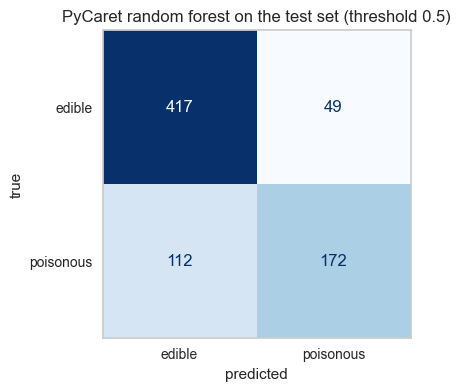

In [7]:
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(test_df[TARGET], (p_poisonous["test"] >= 0.5).astype(int),
                                        display_labels=["edible", "poisonous"], cmap="Blues", colorbar=False, ax=ax)
ax.set(title="PyCaret random forest on the test set (threshold 0.5)", xlabel="predicted", ylabel="true")
ax.grid(False)
plt.show()

**Interpretation**
- The scores are in line with cross-validation: AUC 0.831 (CV), 0.818 (validation), 0.838 (test). The random forest is not overfitting in a way that hurts: its deep trees fit the training set almost perfectly, but that does not carry over as an optimistic score on new rows, thanks to the averaging.
- Compared with the baseline (notebook 03) on the test set: accuracy rises from 68% to 79% and AUC from 0.71 to 0.84, with **far fewer false alarms** (49 instead of 137). But recall is about the same (0.61 vs. 0.63): the random forest still misses 112 of the 284 poisonous test mushrooms. It is a much better model that uses the wrong threshold for our purpose, because it was trained without class weights and threshold 0.5 treats both errors as equally bad.
- So the next gain is clear: with this AUC, lowering the threshold (or using class weights) should raise recall a lot while keeping precision acceptable. That is the first thing to do in `05`.

## 6. What does the random forest look at?

The feature importance of a random forest measures how much each feature reduces impurity over all splits in all trees (mean decrease in impurity). We compare it with what the logistic regression in notebook 03 relied on.

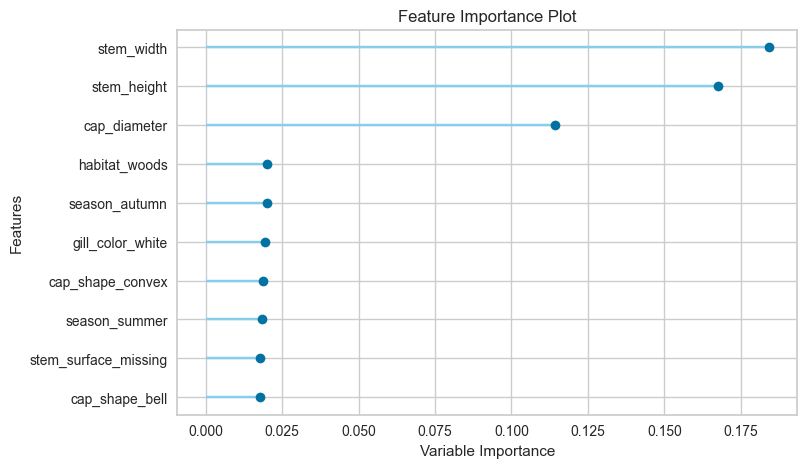

In [8]:
plot_model(best_model, plot="feature")

**Interpretation**
- The random forest relies mostly on the **three size measures**, the features the logistic regression hardly used (small coefficients in notebook 03). The EDA showed that each size on its own separates the classes only weakly (small effect sizes, EDA 6.4), but trees can combine them with each other and with categories ("small cap **and** thin stem **and** woods"). That is where the jump from AUC 0.71 to 0.84 comes from.
- A caveat: impurity-based importance is biased towards features with many possible split points, like continuous measurements. One-hot columns can only be split once. So the ranking overstates the numerical features somewhat; permutation importance (in `07_model_comparison.ipynb`) is a fairer check.

## 7. Saving the model

`save_model` stores the complete PyCaret pipeline (imputation, encoding, transformation, scaling and the random forest) as one `.pkl` file.

**Why not `finalize_model`?** PyCaret's usual last step retrains the model on all data of the experiment: train **and** the hold-out set, which here is our validation set. Then the validation set would no longer be unseen, and `07_model_comparison.ipynb` could not use it to compare this model fairly with the others. So we save the model trained on the training set only.

This model is saved for the comparison, not for deployment: loading it requires PyCaret in the API. The deployed model will be a plain scikit-learn pipeline from the `05` notebooks, like the baseline.

In [9]:
save_model(best_model, str(MODEL_PATH), verbose=False)
size_mb = MODEL_PATH.with_suffix(".pkl").stat().st_size / 1e6
print(f"Saved {MODEL_PATH.with_suffix('.pkl')}  ({size_mb:.1f} MB, GitHub limit is 100 MB)")

Saved models\mushroom_pycaret_rf.pkl  (15.2 MB, GitHub limit is 100 MB)


## 8. Storing the metrics

We add the test result to the shared `models/metrics.csv` (rows of this notebook are replaced when it is run again) and show all models so far.

In [10]:
new_rows = pd.DataFrame(results)
if METRICS_PATH.exists():
    metrics = pd.read_csv(METRICS_PATH)
    metrics = pd.concat([metrics[metrics["notebook"] != NOTEBOOK], new_rows], ignore_index=True)
else:
    metrics = new_rows
metrics.to_csv(METRICS_PATH, index=False)
metrics.round(3)

,model,notebook,split,threshold,accuracy,recall_poisonous,precision_poisonous,f1_poisonous,roc_auc,missed_poisonous,false_alarms
0,random forest (tuned),05a_model_random_forest,validation,0.500,0.800,0.634,0.796,0.706,0.817,104,46
1,"random forest (tuned, recall 0.90)",05a_model_random_forest,validation,0.161,0.564,0.901,0.461,0.610,0.817,28,299
2,random forest (tuned),05a_model_random_forest,test,0.500,0.795,0.613,0.798,0.693,0.842,110,44
3,"random forest (tuned, recall 0.90)",05a_model_random_forest,test,0.161,0.579,0.930,0.471,0.626,0.842,20,296
4,gradient boosting (tuned),05b_model_gradient_boosting,validation,0.500,0.799,0.634,0.793,0.705,0.819,104,47
5,"gradient boosting (tuned, recall 0.90)",05b_model_gradient_boosting,validation,0.139,0.573,0.901,0.467,0.615,0.819,28,292
6,gradient boosting (tuned),05b_model_gradient_boosting,test,0.500,0.808,0.623,0.827,0.711,0.847,107,37
7,"gradient boosting (tuned, recall 0.90)",05b_model_gradient_boosting,test,0.139,0.576,0.940,0.470,0.627,0.847,17,301
8,ensemble (stack: forest + boosting),05c_model_ensemble,validation,0.500,0.801,0.669,0.776,0.718,0.821,94,55
9,"ensemble (stack: forest + boosting), recall 0.90",05c_model_ensemble,validation,0.130,0.575,0.901,0.468,0.616,0.821,28,291


## 9. Conclusion & next steps

- **Tree ensembles are the right model family** for this data: random forest, LightGBM and extra trees lead the comparison (AUC 0.80–0.83 in cross-validation), linear models trail far behind (≈ 0.70). This confirms the EDA (overlapping classes, weak single features) and the baseline notebook.
- **PyCaret's best model** is the default random forest: test accuracy ≈ 79%, AUC ≈ 0.84 (baseline: 68%, 0.71), and only a third of the baseline's false alarms. Validation (AUC 0.82) and cross-validation (0.83) tell the same story.
- **Automatic tuning and blending did not help**, in cross-validation and on the validation set. PyCaret's random search is limited to shallow trees, which do worse here; blending three similar tree models adds nothing.
- **Recall is the open problem**: even the best model misses about 40% of the poisonous mushrooms at threshold 0.5.

**Plan for the `05_model_*` notebooks** (tuning with cross-validation on the training set, threshold on the validation set):
- Tune the **random forest** and **gradient boosting (LightGBM or scikit-learn's `HistGradientBoostingClassifier`)** with our own search spaces, including deep trees for the forest.
- **Choose the decision threshold** on the validation set for a target recall on poisonous mushrooms (05a chooses 0.90), then report the precision that costs.
- Test the open question left by the data prep notebook: removing suspected flipped labels from the training set (imputation and `spore_print_color` were already answered in 02, section 9.2).
- Combine models of *different* families in a heterogeneous ensemble (`05c`), since blending similar trees did not help.